#**Importación de Librerías para el Análisis de Datos y Modelado de Machine Learning**

In [ ]:
# Importa la librería pandas para manipulación y análisis de datos en estructuras tipo DataFrame
import pandas as pd

# Importa matplotlib para crear gráficos
import matplotlib.pyplot as plt

# Importa seaborn para visualizaciones estadísticas más avanzadas y estilizadas
import seaborn as sns

# Importa numpy para operaciones matemáticas y manejo de arreglos numéricos
import numpy as np

# Permite aplicar diferentes transformaciones a distintas columnas de un dataset
from sklearn.compose import make_column_transformer

# Codificador que convierte variables categóricas en variables numéricas (one-hot encoding)
from sklearn.preprocessing import OneHotEncoder

# Función para dividir el dataset en datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo de Random Forest para tareas de regresión
from sklearn.ensemble import RandomForestRegressor

# Algoritmo K-Nearest Neighbors para clasificación
from sklearn.neighbors import KNeighborsClassifier

# Escalador que normaliza los valores entre 0 y 1
from sklearn.preprocessing import MinMaxScaler

# Función para generar la matriz de confusión
from sklearn.metrics import confusion_matrix

# Herramienta para visualizar gráficamente la matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

# Métricas de evaluación para modelos de clasificación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Métricas de evaluación para modelos de regresión
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Técnica de sobremuestreo para balancear datasets desbalanceados
from imblearn.over_sampling import SMOTE

#**Carga y Exploración Inicial del Conjunto de Datos**

In [ ]:
datos = pd.read_csv('/content/TelecomX_Datos_limpio.csv')
datos.head(3)

,ID_Cliente,Abandono,Genero,TerceraEdad,Socio,Dependientes,Antiguedad,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,StreamingTV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.12
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.93
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.38


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7043 non-null   object 
 1   Abandono                 7043 non-null   int64  
 2   Genero                   7043 non-null   object 
 3   TerceraEdad              7043 non-null   int64  
 4   Socio                    7043 non-null   int64  
 5   Dependientes             7043 non-null   int64  
 6   Antiguedad               7043 non-null   int64  
 7   Servicio_Telefonico      7043 non-null   int64  
 8   Lineas_Multiples         7043 non-null   int64  
 9   Servicio_Internet        7043 non-null   object 
 10  Seguridad_Online         7043 non-null   int64  
 11  Copia_Seguridad_Online   7043 non-null   int64  
 12  Proteccion_Dispositivo   7043 non-null   int64  
 13  Soporte_Tecnico          7043 non-null   int64  
 14  StreamingTV             

##Eliminación de Columnas Irrelevantes

In [ ]:
datos = datos.drop('ID_Cliente',axis = 1)
datos.sample(1)

,Abandono,Genero,TerceraEdad,Socio,Dependientes,Antiguedad,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,Seguridad_Online,...,Proteccion_Dispositivo,Soporte_Tecnico,StreamingTV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
2320,0,Male,0,0,0,3,1,0,Fiber optic,0,...,0,0,1,1,Month-to-month,1,Electronic check,92.0,266.8,2.97


## Codificacion de varibles

In [ ]:
X = datos.drop('Abandono',axis = 1)
y = datos['Abandono']

In [ ]:
columnas = X.columns

In [ ]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    [ 'Genero','Servicio_Internet', 'Contrato', 'Metodo_Pago']
),
    remainder = 'passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

In [ ]:
X = one_hot.fit_transform(X)

In [ ]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__Genero_Male',
       'onehotencoder__Servicio_Internet_DSL',
       'onehotencoder__Servicio_Internet_Fiber optic',
       'onehotencoder__Servicio_Internet_No',
       'onehotencoder__Contrato_Month-to-month',
       'onehotencoder__Contrato_One year',
       'onehotencoder__Contrato_Two year',
       'onehotencoder__Metodo_Pago_Bank transfer (automatic)',
       'onehotencoder__Metodo_Pago_Credit card (automatic)',
       'onehotencoder__Metodo_Pago_Electronic check',
       'onehotencoder__Metodo_Pago_Mailed check',
       'remainder__TerceraEdad', 'remainder__Socio',
       'remainder__Dependientes', 'remainder__Antiguedad',
       'remainder__Servicio_Telefonico', 'remainder__Lineas_Multiples',
       'remainder__Seguridad_Online', 'remainder__Copia_Seguridad_Online',
       'remainder__Proteccion_Dispositivo', 'remainder__Soporte_Tecnico',
       'remainder__StreamingTV', 'remainder__Streaming_Peliculas',
       'remainder__Facturacion_Electronica',
       

In [ ]:
columns = [col.replace('remainder__', '').replace('onehotencoder__', '') for col in one_hot.get_feature_names_out()]
X = pd.DataFrame(X, columns=columns)
X.sample(3)

,Genero_Male,Servicio_Internet_DSL,Servicio_Internet_Fiber optic,Servicio_Internet_No,Contrato_Month-to-month,Contrato_One year,Contrato_Two year,Metodo_Pago_Bank transfer (automatic),Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,...,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,StreamingTV,Streaming_Peliculas,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
4618,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.45,911.6,0.85
4501,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,74.15,811.8,2.39
6205,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,64.30,3410.6,2.07


##Verificación de la Proporción de Cancelación (Churn)

In [ ]:
y.value_counts()

,count
Abandono,
0,5174
1,1869


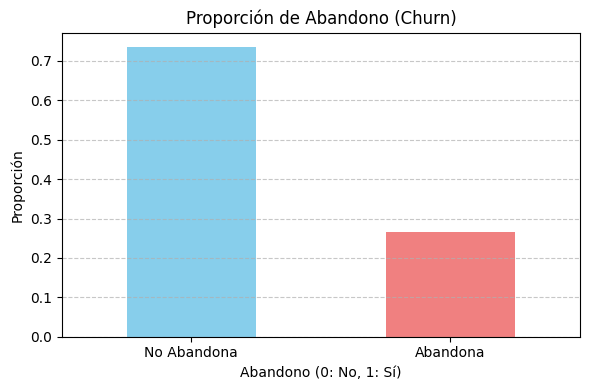

In [ ]:
abandono_counts = y.value_counts(normalize=True)

plt.figure(figsize=(6, 4))
abandono_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Proporción de Abandono (Churn)')
plt.xlabel('Abandono (0: No, 1: Sí)')
plt.ylabel('Proporción')
plt.xticks(ticks=[0, 1], labels=['No Abandona', 'Abandona'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Balanceo de Clases utilizando la tecnica de oversampling

In [ ]:
oversampling = SMOTE()
X_balanceada,y_balanceada = oversampling.fit_resample(X,y)

In [ ]:
y_balanceada.value_counts(normalize=True)

,proportion
Abandono,
0,0.5
1,0.5


#**Correlación y Selección de Variables**

##Análisis de Correlación

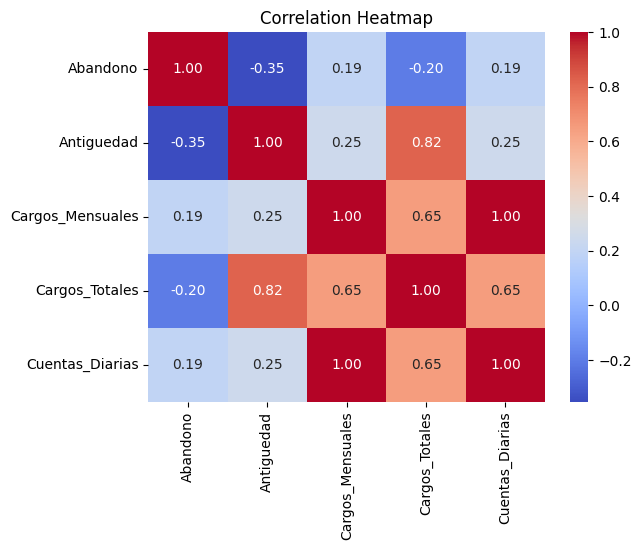

In [ ]:
columnas_numericas = ['Antiguedad','Cargos_Mensuales','Cargos_Totales','Cuentas_Diarias']
plt.figure()
data = pd.concat([pd.DataFrame(y, columns=['Abandono']), X[columnas_numericas] ], axis=1)
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##Análisis Dirigido

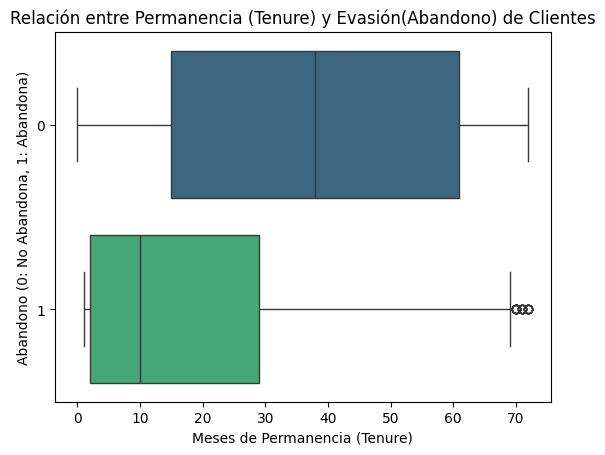

In [ ]:
sns.boxplot(x='Antiguedad', y='Abandono', data=data, palette='viridis', hue='Abandono', legend=False, orient='h')
plt.title("Relación entre Permanencia (Tenure) y Evasión(Abandono) de Clientes")
plt.xlabel('Meses de Permanencia (Tenure)')
plt.ylabel('Abandono (0: No Abandona, 1: Abandona)')
plt.show()

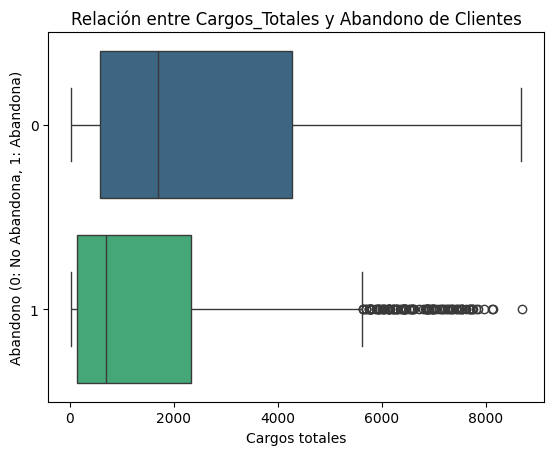

In [ ]:
sns.boxplot(x='Cargos_Totales', y='Abandono', data=data, palette='viridis', hue='Abandono', legend=False, orient='h')
plt.title("Relación entre Cargos_Totales y Abandono de Clientes")
plt.xlabel('Cargos totales')
plt.ylabel('Abandono (0: No Abandona, 1: Abandona)')
plt.show()

#**Modelado Predictivo**

##Separación de Datos

In [ ]:
X_temp,x_test,y_temp,y_test = train_test_split(X_balanceada,y_balanceada,test_size=0.2, random_state=13)
x_train,x_val,y_train,y_val = train_test_split(X_temp,y_temp,random_state=13)

##Creación de Modelos

In [ ]:
def mostrar_metricas_clasificacion(y_true, y_pred, titulo_matriz='Matriz de Confusión'):
    """
    Calcula y muestra métricas de clasificación (Exactitud, Precisión, Recall, F1-score)
    y la matriz de confusión.

    Args:
        y_true (array-like): Etiquetas verdaderas.
        y_pred (array-like): Etiquetas predichas por el modelo.
        titulo_matriz (str): Título para el gráfico de la matriz de confusión.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Métricas de Clasificación:")
    print(f"  Exactitud (Accuracy): {accuracy:.4f}")
    print(f"  Precisión:            {precision:.4f}")
    print(f"  Recall:               {recall:.4f}")
    print(f"  F1-score:             {f1:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(titulo_matriz)
    plt.show()

###Modelo 1 RandomForestRegressor

In [ ]:
modelo_1 = RandomForestRegressor(max_depth=5,random_state=13)
modelo_1.fit(x_train,y_train)

RandomForestRegressor(max_depth=5, random_state=13)

In [ ]:
y_previst_continuous = modelo_1.predict(x_val)
y_previst = (y_previst_continuous > 0.5).astype(int)

Métricas de Clasificación:
  Exactitud (Accuracy): 0.8324
  Precisión:            0.8257
  Recall:               0.8470
  F1-score:             0.8362


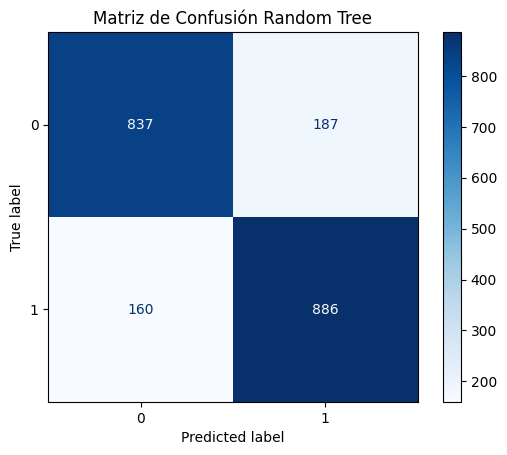

In [ ]:
mostrar_metricas_clasificacion(y_val,y_previst,'Matriz de Confusión Random Tree')

###Modelo 2 KNeighborsClassifier

In [ ]:
normalizacion = MinMaxScaler()
x_train_normalizado = normalizacion.fit_transform(x_train)

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(x_train_normalizado,y_train)

KNeighborsClassifier()

In [ ]:
x_test_normalizado = normalizacion.transform(x_test)

In [ ]:
knn.score(x_test_normalizado,y_test)

0.7782608695652173

Métricas de Clasificación:
  Exactitud (Accuracy): 0.7783
  Precisión:            0.7147
  Recall:               0.8988
  F1-score:             0.7963


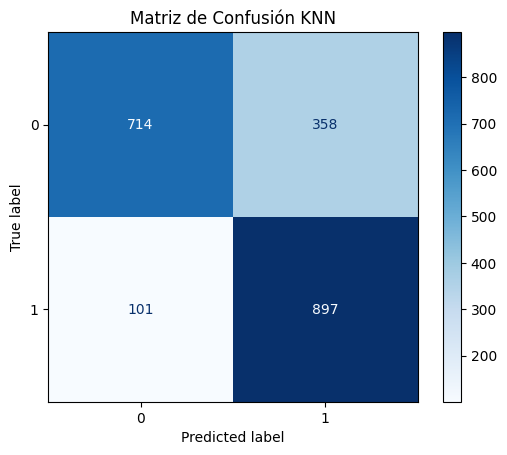

In [ ]:
y_previst_knn = knn.predict(x_test_normalizado)
mostrar_metricas_clasificacion(y_test, y_previst_knn, 'Matriz de Confusión KNN')

# Análisis Comparativo de Modelos

En el desarrollo de este proyecto se implementaron dos modelos de aprendizaje automático con el objetivo de predecir el abandono de clientes (churn) en la empresa TelecomX: **Random Forest** y **K-Nearest Neighbors (KNN)**. Ambos modelos presentan enfoques diferentes para realizar predicciones, lo que permite comparar su desempeño y determinar cuál se adapta mejor al problema analizado.

El modelo **Random Forest** se basa en un método de ensamble que combina múltiples árboles de decisión para generar una predicción final. Esta característica le permite capturar relaciones complejas entre las variables del conjunto de datos, además de reducir el riesgo de sobreajuste. Como resultado, este modelo tiende a ofrecer predicciones más estables y un mejor rendimiento general en problemas con múltiples variables y patrones no lineales.

Por otro lado, el modelo **K-Nearest Neighbors (KNN)** funciona mediante la comparación de cada observación con las instancias más cercanas dentro del conjunto de datos. La clasificación se realiza en función de la mayoría de vecinos más próximos. Aunque este método es sencillo e intuitivo, su rendimiento puede verse afectado cuando el dataset contiene muchas variables o cuando existen patrones complejos que no pueden capturarse únicamente mediante la proximidad entre datos.

En los resultados obtenidos, el modelo **Random Forest** mostró un desempeño más equilibrado en las métricas de evaluación, lo que indica una mayor capacidad para clasificar correctamente tanto a los clientes que permanecen en la empresa como a aquellos que deciden abandonarla. En contraste, el modelo **KNN** presentó una capacidad aceptable para identificar casos de abandono, pero con menor precisión general, lo que puede generar un mayor número de clasificaciones incorrectas.

Desde una perspectiva práctica, estos resultados sugieren que **Random Forest es el modelo más adecuado para este problema**, ya que logra un mejor equilibrio entre precisión, estabilidad y capacidad de generalización. Además, este modelo permite analizar la importancia de las variables, lo que facilita identificar los factores que influyen con mayor peso en el abandono de clientes.


#**Interpretación y Conclusiones**

##Análisis de la Importancia de las Variables

###Modelo 1: RandomForestRegressor

In [ ]:
importances_modelo_1 = modelo_1.feature_importances_

In [ ]:
feature_importances = pd.DataFrame({'Features':X.columns,'Importances':(importances_modelo_1*100).round(2)}).sort_values('Importances',ascending=False)
feature_importances.head(10)

,Features,Importances
4,Contrato_Month-to-month,60.32
9,Metodo_Pago_Electronic check,18.59
14,Antiguedad,3.63
2,Servicio_Internet_Fiber optic,3.58
17,Seguridad_Online,2.08
5,Contrato_One year,2.03
6,Contrato_Two year,1.86
23,Facturacion_Electronica,1.63
24,Cargos_Mensuales,1.55
25,Cargos_Totales,0.83


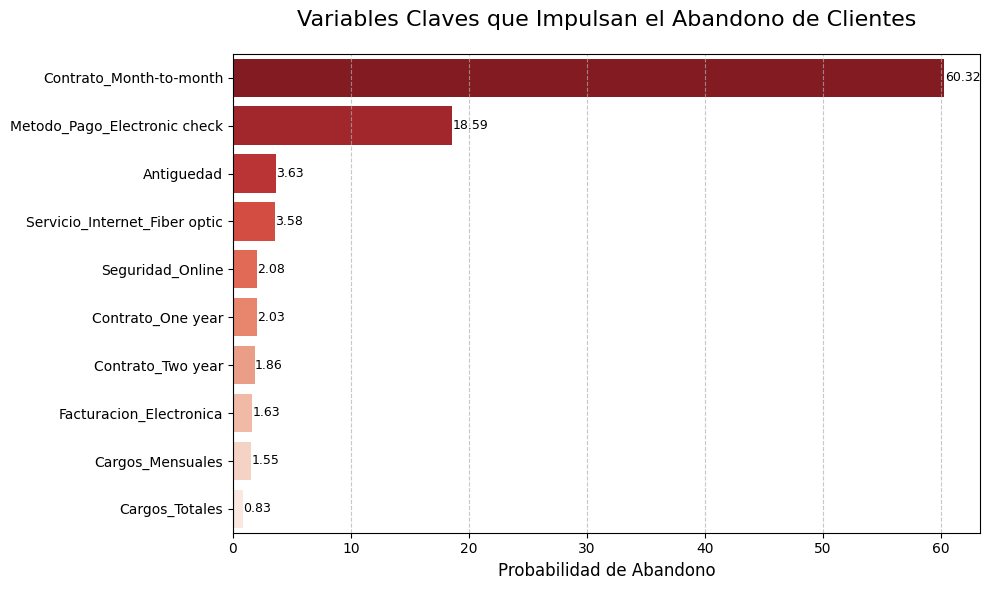

In [ ]:

top_positive = feature_importances.head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Importances", y="Features", data=top_positive, palette="Reds_r", hue="Features", legend=False)
plt.title("Variables Claves que Impulsan el Abandono de Clientes", fontsize=16, pad=20)
plt.xlabel("Probabilidad de Abandono", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.02, p.get_y() + p.get_height() / 2,
             f'{width:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

###Modelo 2: KNeighborsClassifier

In [ ]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance = permutation_importance(knn, x_test_normalizado, y_test, n_repeats=10, random_state=13)

# Get the mean importance of each feature
feature_importances_knn = pd.DataFrame({
    'Features': X.columns,
    'Importances': perm_importance.importances_mean
}).sort_values('Importances', ascending=False)

display(feature_importances_knn.head(10))

,Features,Importances
4,Contrato_Month-to-month,0.020870
14,Antiguedad,0.017391
6,Contrato_Two year,0.016135
0,Genero_Male,0.015700
10,Metodo_Pago_Mailed check,0.014348
5,Contrato_One year,0.013913
9,Metodo_Pago_Electronic check,0.012995
12,Socio,0.012947
17,Seguridad_Online,0.011256
7,Metodo_Pago_Bank transfer (automatic),0.011063


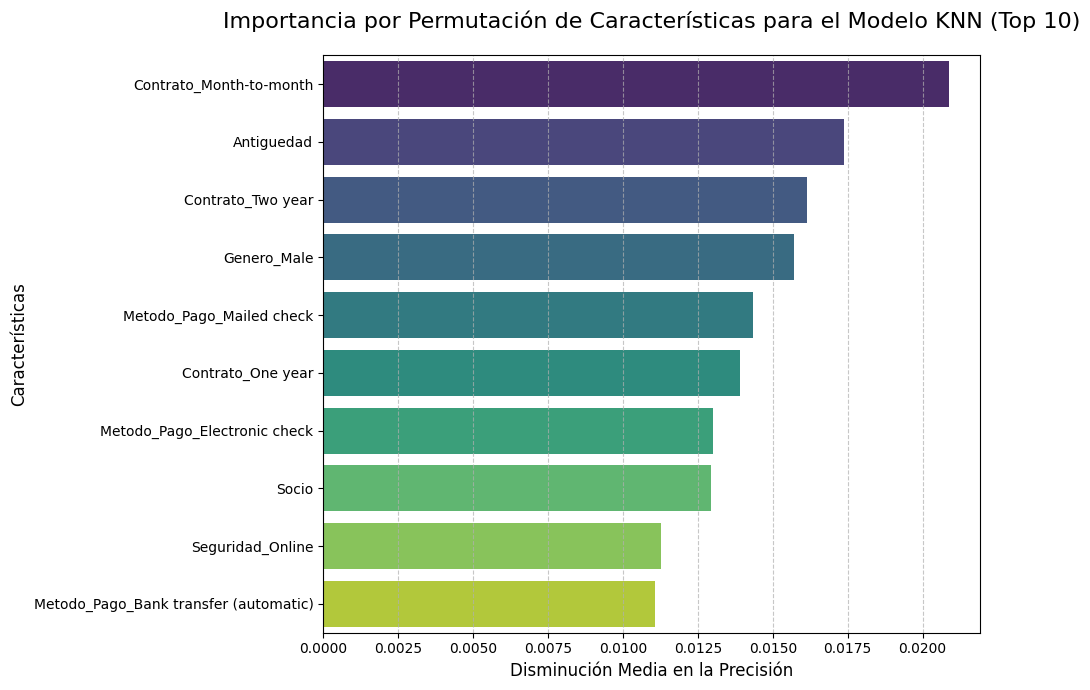

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize permutation importance
plt.figure(figsize=(10, 7))
sns.barplot(x='Importances', y='Features', data=feature_importances_knn.head(10), palette='viridis', hue='Features', legend=False)
plt.title('Importancia por Permutación de Características para el Modelo KNN (Top 10)', fontsize=16, pad=20)
plt.xlabel('Disminución Media en la Precisión', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Informe Detallado del Análisis

## Introducción

El abandono de clientes, conocido como **churn**, es un problema relevante en el sector de telecomunicaciones. Cuando un cliente decide cancelar un servicio o cambiar de proveedor, la empresa experimenta una pérdida directa de ingresos y debe invertir recursos adicionales para captar nuevos usuarios. Por esta razón, resulta fundamental comprender los factores que influyen en la decisión de abandono y desarrollar herramientas que permitan anticipar este comportamiento.

En este proyecto se aplicaron técnicas de análisis de datos y aprendizaje automático para estudiar el comportamiento de los clientes de TelecomX y construir modelos predictivos capaces de identificar patrones asociados al abandono del servicio.

---

## Preparación de los Datos

Antes de aplicar los modelos de aprendizaje automático, se realizó un proceso de preparación y transformación de los datos con el objetivo de garantizar la calidad del análisis.

En primer lugar, se cargó el conjunto de datos previamente limpiado y se verificó la estructura del dataset, incluyendo los tipos de datos y la presencia de valores faltantes. Posteriormente, se aplicó **One-Hot Encoding** para convertir las variables categóricas en variables numéricas, permitiendo que los algoritmos de machine learning pudieran procesarlas correctamente.

También se aplicó una **normalización de los datos mediante MinMaxScaler**, con el objetivo de llevar todas las variables a una escala común entre 0 y 1. Esto es especialmente importante para algoritmos como KNN, que dependen de la distancia entre observaciones.

Finalmente, el conjunto de datos se dividió en **datos de entrenamiento y datos de prueba**, lo que permitió evaluar el desempeño de los modelos utilizando información que no fue utilizada durante el proceso de entrenamiento.

---

## Balanceo de Datos

En problemas de churn es común encontrar **desbalance de clases**, donde la mayoría de los clientes permanecen en la empresa y solo una minoría abandona el servicio. Este desequilibrio puede afectar el desempeño de los modelos de aprendizaje automático.

Para mitigar este problema, se utilizó la técnica **SMOTE (Synthetic Minority Over-sampling Technique)**, la cual genera ejemplos sintéticos de la clase minoritaria con el objetivo de equilibrar la distribución de las clases. Esto permite que los modelos aprendan de forma más efectiva los patrones asociados al abandono de clientes.

---

## Resultados de los Modelos

Después de entrenar los modelos, se evaluó su desempeño utilizando diferentes métricas de clasificación, entre ellas:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**

Estas métricas permiten evaluar el desempeño del modelo desde diferentes perspectivas, considerando tanto la cantidad de predicciones correctas como la capacidad de identificar correctamente los casos de abandono.

El modelo **Random Forest** mostró un desempeño superior en la mayoría de las métricas, lo que indica que es capaz de capturar de manera más efectiva los patrones presentes en los datos. Esto se debe principalmente a su capacidad para manejar múltiples variables y relaciones complejas dentro del dataset.

Por su parte, el modelo **KNN** mostró un rendimiento aceptable, aunque más sensible a la distribución de los datos y a la presencia de variables con diferentes escalas.

---

## Interpretación de Resultados

El análisis realizado sugiere que ciertos factores del cliente pueden estar relacionados con una mayor probabilidad de abandono del servicio. Entre estos factores pueden encontrarse variables como el tipo de contrato, el costo mensual del servicio y el tiempo de permanencia del cliente en la empresa.

Comprender estos patrones permite a la empresa anticipar posibles cancelaciones y tomar medidas preventivas para mejorar la retención de clientes.

---

## Conclusión

El uso de modelos de aprendizaje automático en el análisis de churn permite identificar patrones relevantes en el comportamiento de los clientes y generar predicciones útiles para la toma de decisiones.

En este estudio, el modelo **Random Forest** demostró ofrecer un mejor desempeño en comparación con el modelo **K-Nearest Neighbors**, debido a su mayor capacidad para capturar relaciones complejas entre las variables del dataset y su mayor estabilidad en las predicciones.

La implementación de este tipo de modelos puede ayudar a TelecomX a desarrollar estrategias de retención más efectivas, reducir la pérdida de clientes y mejorar la competitividad en el mercado de telecomunicaciones.